# **Delivery Performance Optimization:**

> **`Problem`**:   
The company needs to improve its on-time delivery performance to enhance customer satisfaction and competitive advantage.

> **`Key Questions`**:     
> - What is the current on-time delivery rate across different warehouse blocks?
> - Which factors most significantly impact delivery timeliness?
> - How can we predict which shipments are likely to be delayed?

> **`Business Impact`**:   
Poor delivery performance leads to customer dissatisfaction, negative reviews, and potential loss of business to competitors.

In [2]:
import pandas as pd 
import numpy as np 
import warnings as war 
war.filterwarnings("ignore")
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
data= pd.read_json("https://raw.githubusercontent.com/rajesh-coventry/Projects/refs/heads/master/02_Data_Visuallization/05_E-Commerce_Shipping/ecommerce_shipping_data.json")
data.shape

(10999, 12)

In [4]:
data.head(3)

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1


## **1. Data Exploration and Quality Assessment:**

In [5]:
# Descriptive statistics for numerical columns: 
data.describe()

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.00000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000
mean,5500.00000,4.054459,2.990545,210.196836,3.567597,13.373216,3634.016729,0.596691
std,3175.28214,1.141490,1.413603,48.063272,1.522860,16.205527,1635.377251,0.490584
min,1.00000,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000,0.000000
25%,2750.50000,3.000000,2.000000,169.000000,3.000000,4.000000,1839.500000,0.000000
50%,5500.00000,4.000000,3.000000,214.000000,3.000000,7.000000,4149.000000,1.000000
75%,8249.50000,5.000000,4.000000,251.000000,4.000000,10.000000,5050.000000,1.000000
max,10999.00000,7.000000,5.000000,310.000000,10.000000,65.000000,7846.000000,1.000000


**Outliers Detection:**

In [6]:
# Outliers Detection and save outliers in series for each column:
outliers = {}
for col in data.select_dtypes(include=['int64', 'float64']).columns:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers[col] = data[(data[col] < lower_bound) | (data[col] > upper_bound)].index

In [7]:
data.select_dtypes(include=['int64', 'float64']).columns

Index(['ID', 'Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product',
       'Prior_purchases', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='object')

In [ ]:
outliers["ID"], outliers["Customer_rating"], outliers["Customer_care_calls"], outliers["Cost_of_the_Product"], outliers["Weight_in_gms"], outliers["Reached.on.Time_Y.N"]

# These columns have no outlier values

(Index([], dtype='int64'),
 Index([], dtype='int64'),
 Index([], dtype='int64'),
 Index([], dtype='int64'),
 Index([], dtype='int64'),
 Index([], dtype='int64'))

Following two columns `'Prior_purchases'` and, `"Discount_offered"`  contains outlier values:

In [9]:
out1= outliers["Prior_purchases"]
out1= out1.to_frame(name= "out11")
out1.head(3)

,out11
37,37
62,62
74,74


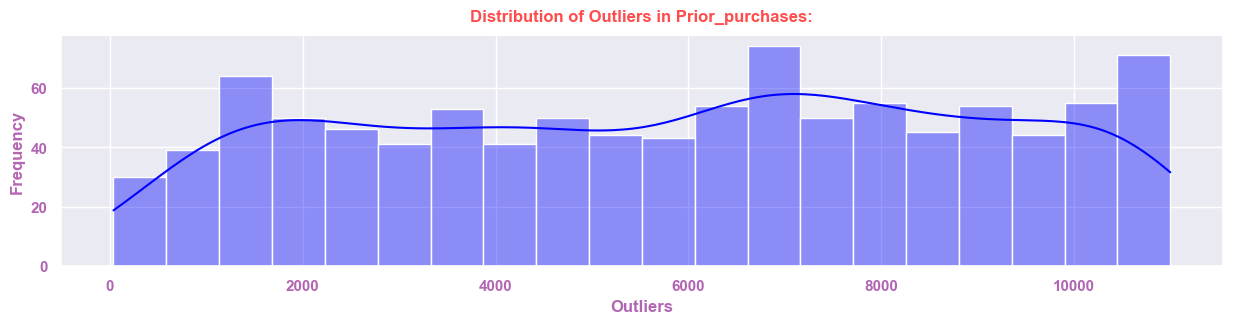

In [28]:
plt.figure(figsize=(15, 3))
sns.set_theme(context="notebook", style="darkgrid")
sns.histplot(data=out1, x="out11", kde=True, bins=20, color= "blue", alpha=0.4)
plt.title("Distribution of Outliers in Prior_purchases:", fontsize=12, fontweight="bold", color="Red", pad=10, alpha=0.7)
plt.xlabel("Outliers", color="purple", fontweight="bold", alpha=0.6)
plt.ylabel("Frequency", color="purple", fontweight="bold", alpha=0.6)    
plt.xticks(alpha=0.6, color="purple", fontweight="bold")
plt.yticks(alpha=0.6, color="purple", fontweight="bold")
plt.show()

In [17]:
outliers["Discount_offered"]
out2= outliers["Discount_offered"].to_frame(name= "out22")
out2.head(3)

,out22
0,0
1,1
2,2


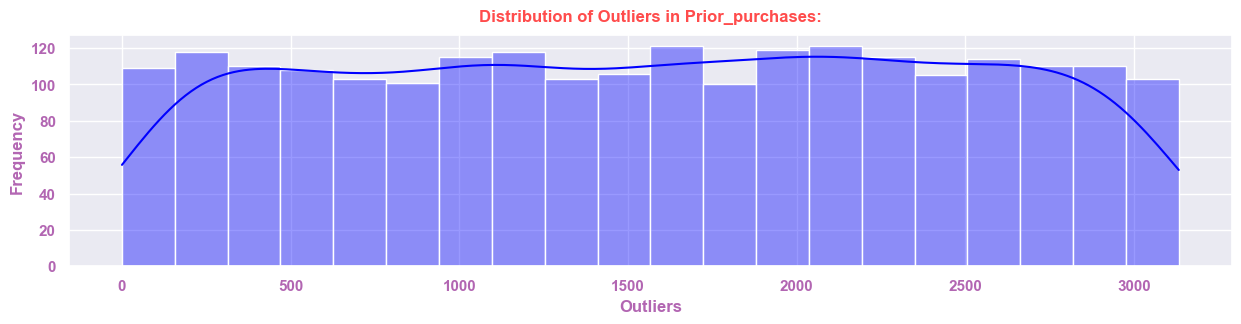

In [30]:
plt.figure(figsize=(15, 3))
sns.set_theme(context="notebook", style="darkgrid")
sns.histplot(data=out2, x="out22", kde=True, bins=20, alpha= 0.4, color= "blue")
plt.title("Distribution of Outliers in Prior_purchases:", fontsize=12, fontweight="bold", color="Red", pad=10, alpha=0.7)
plt.xlabel("Outliers", color="purple", fontweight="bold", alpha=0.6)
plt.ylabel("Frequency", color="purple", fontweight="bold", alpha=0.6)    
plt.xticks(alpha=0.6, color="purple", fontweight="bold")
plt.yticks(alpha=0.6, color="purple", fontweight="bold")
plt.show()

**Box plots for the distribution of all numeric columns:**

In [55]:
data.select_dtypes(include=['int64', 'float64']).columns

Index(['ID', 'Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product',
       'Prior_purchases', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='object')

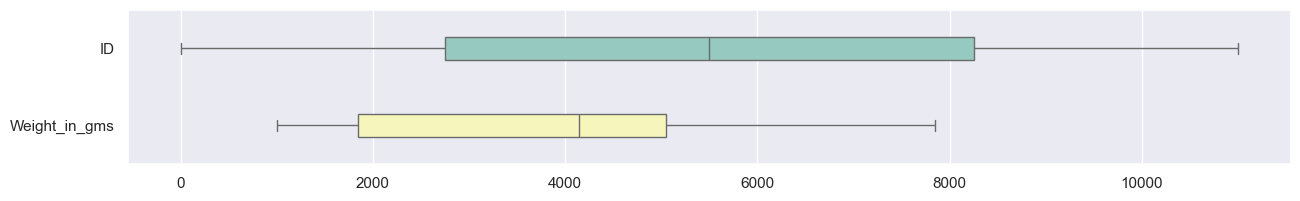

In [68]:
# Box plot for the distribution of all numeric columns:
plt.figure(figsize=(15, 2))
sns.set_theme(context="notebook", style="darkgrid")
sns.boxplot(data=data[["ID", "Weight_in_gms"]], orient="h", palette="Set3", width= 0.3)
plt.show()

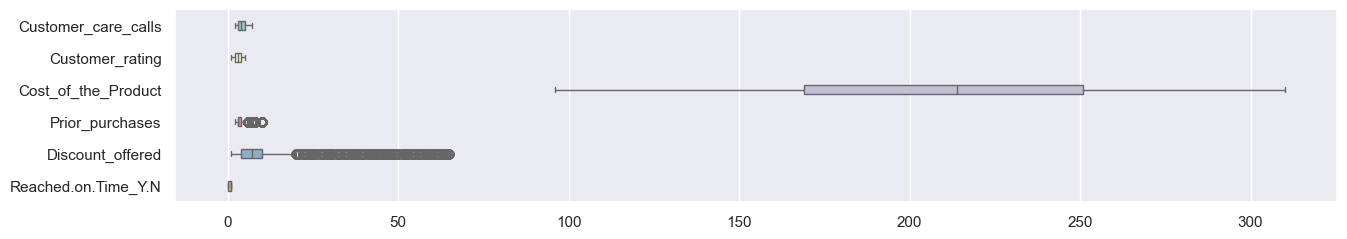

In [63]:
plt.figure(figsize=(15, 2.5))
sns.set_theme(context="notebook", style="darkgrid")
sns.boxplot(data=data[['Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product',
       'Prior_purchases', 'Discount_offered',
       'Reached.on.Time_Y.N']], orient="h", palette="Set3", width= 0.3)
plt.show()

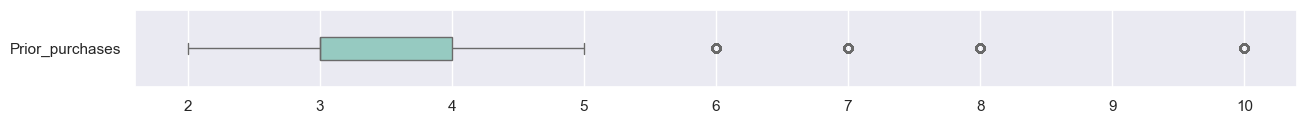

In [66]:
plt.figure(figsize=(15, 1))
sns.set_theme(context="notebook", style="darkgrid")
sns.boxplot(data=data[['Prior_purchases']], orient="h", palette="Set3", width= 0.3)
plt.show()

<Axes: >

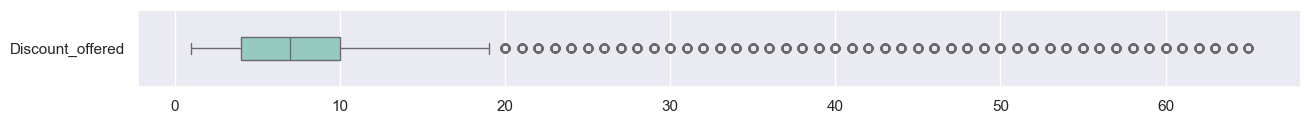

In [67]:
plt.figure(figsize=(15, 1))
sns.set_theme(context="notebook", style="darkgrid")
sns.boxplot(data=data[['Discount_offered']], orient="h", palette="Set3", width= 0.3)

-----
-----
-----
-----
---

## **2. Overall Delivery Performance Baseline:**